# **Preprocessing**

##### Import libraries we will use

In [1]:
import pymongo
from datetime import datetime, timedelta, timezone #import packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from scipy.signal import savgol_filter
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import os
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings("ignore")
import json
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from urllib.parse import quote_plus
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    max_error
)
from statsmodels.tsa.statespace.sarimax import SARIMAX


* ##### We migrated from _Atlas MongoDB_ to a local _MongoDB Server_ for faster CRUD operations
* ##### Created a cursor that will aggregate and return all columns excpet id. We dont need it

In [2]:

load_dotenv("credentials.env")
username = os.getenv("MONGO_USERNAME")
password = os.getenv("MONGO_PASSWORD")

host = os.getenv("MONGO_HOST")
port = os.getenv("MONGO_PORT")

db_name = os.getenv("MONGO_DB")
collection_name = os.getenv("MONGO_COLLECTION")

if username and password:

    username = quote_plus(username)
    password = quote_plus(password)

    uri = (
        f"mongodb://{username}:{password}"
        f"@{host}:{port}/"
    )

else:

    uri = f"mongodb://{host}:{port}/"

myclient = pymongo.MongoClient(uri)

mydb = myclient[db_name]
input = mydb[collection_name]

cursor = input.find({}, {"_id": 0})

df = pd.DataFrame(list(cursor))

print(len(df))

16813


##### Due to battery drainage our TelosB sensor stopped working at around _20-05-2026T09:48:55:700 local time_. 
> ##### We tried to change batteries on our TelosB later on but we had already gathered enough data (3.5 days)
##### During the first day we saw a huge spike (>1200) in our grafana interface in the solar & light sensors and we decedide exclude it from our data since it never repeated. We considered it an outlier. Data taken from other sensors at that time also get deleted and will be filled later on.

In [3]:
time_cutoff = {"timestamp" : {"$gt": datetime(2026,5, 20, 9, 49, 55, 65)}}
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

cutoff = pd.Timestamp(
    year=2026,
    month=5,
    day=20,
    hour=9,
    minute=49,
    second=55,
    microsecond=647000,
    tz="UTC"
)

df = df[
    (df["timestamp"] < cutoff) &
    (df["light_raw"] < 150) &
    (df["solar_raw"] < 150)    #cutoff the data at 150.
]

input.delete_many(time_cutoff)

DeleteResult({'n': 0, 'ok': 1.0}, acknowledged=True)

##### In this step we wanted to see any missed values that did not get transmitted or not appended in the DB(e.g. due to network drop, packet loss etc.) First, we ploted the `.diff` of timestamp and saw that most of the times it fluctuated between 18 - 22 seconds. 
##### Knowing this, we conssidered any difference of more than 24 secs to be a missed measurement. 
##### By using the `abs(diff)` we also checked for any duplicate measurements between each period of 24 secs.


In [4]:
timestamp_cur = input.find({}, {"timestamp": 1, "_id": 0}) # we get only the timestamp

prev = first = next(timestamp_cur)

for i, x in enumerate(timestamp_cur):
    if i == 0:
        continue

    cur = x["timestamp"]
    
    diff = cur - prev["timestamp"]

    if abs(diff) > timedelta(seconds=24):
        print(cur, prev["timestamp"], diff.total_seconds())  #find timestmaps with a delay of more than 24 seconds plus overlapping timestamps

    prev = x

2026-05-17 16:08:45.889000 2026-05-17 16:23:52.424000 -906.535
2026-05-17 16:17:06.071000 2026-05-17 16:11:13.805000 352.266
2026-05-17 16:24:12.406000 2026-05-17 16:17:11.941000 420.465
2026-05-17 16:37:12.311000 2026-05-17 16:35:52.517000 79.794


* ##### If 2 measurements exists in a period of 17 seconds, the first one is kept and the other one is dismissed.
* ##### If after 24 seconds we don't get any measurements we use interpolation to fill out missing values.

In [5]:
def clean_and_interpolate(df):
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

    df = df.sort_values("timestamp").reset_index(drop=True)

    clean_rows = [df.iloc[0]]
    last_kept_time = df.loc[0, "timestamp"]

    for i in range(1, len(df)):
        cur_time = df.loc[i, "timestamp"]
        diff = (cur_time - last_kept_time).total_seconds()

        if diff < 17:
            continue

        clean_rows.append(df.iloc[i])
        last_kept_time = cur_time

    df = pd.DataFrame(clean_rows).reset_index(drop=True) #reset indexes (start from 0)

    df = df.set_index("timestamp") #sort them based on timestmpa

    full_index = []
    times = df.index.to_list()

    for i in range(len(times) - 1):
        cur = times[i]
        nxt = times[i + 1]

        full_index.append(cur)

        diff = (nxt - cur).total_seconds()

        if diff > 24:
            missing_times = pd.date_range(
                start=cur + pd.Timedelta(seconds=20),
                end=nxt - pd.Timedelta(seconds=17),
                freq="20s"
            )

            full_index.extend(missing_times)

    full_index.append(times[-1])

    df = df.reindex(pd.DatetimeIndex(full_index).drop_duplicates().sort_values())

    numeric_cols = df.select_dtypes(include="number").columns
    df[numeric_cols] = df[numeric_cols].interpolate(method="time")

    df = df.reset_index().rename(columns={"index": "timestamp"})

    return df

df = clean_and_interpolate(df)

#### Delay in each msmnt over entries plot.

timestamp           16775
light_raw           16775
temperature_c       16775
humidity_percent    16775
solar_raw           16775
battery_v           16775
dtype: int64


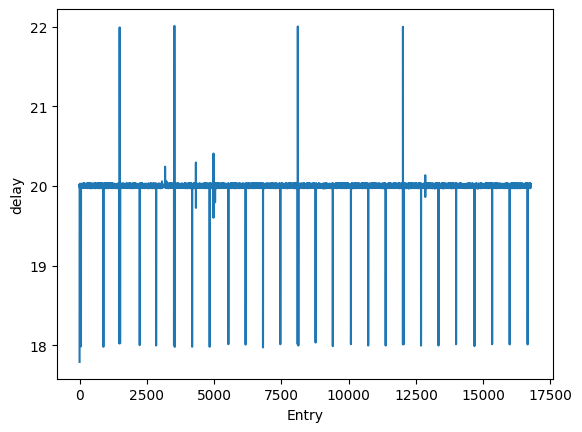

In [6]:
prev = df["timestamp"].iloc[0] #plot the delay to make sure timestamps are good

delay = []

for _, row in df.iterrows():
    diff = (row["timestamp"] - prev).total_seconds()
    delay.append(diff)

    prev = row["timestamp"]

print(df.count())

plt.plot(delay[1:len(delay)-15])

plt.xlabel("Entry")
plt.ylabel("delay")

plt.show()

##### **_z-score_** is used to find outliers for each column.
##### What z-score actually detects is how many std away is a value from its mean. If its more than 3, its an outlier.

In [7]:
numeric_cols = df.select_dtypes(include="number").columns

mask = pd.Series(True, index=df.index) # all cols set to true

for col in numeric_cols:
    mean = df[col].mean() #mean of data
    std = df[col].std() #std of data

    z = (df[col] - mean) / std #compute z-score

    outliers = abs(z) > 3

    print(outliers.sum(), "outliers for:", col)

    mask &= abs(z) < 3

235 outliers for: light_raw
0 outliers for: temperature_c
0 outliers for: humidity_percent
297 outliers for: solar_raw
0 outliers for: battery_v


In [8]:
df = df[mask]

In [9]:
print(len(df)) #check no of entries after z-score cleaning

16472


IQR finds the thressholds for over 75% and under 25% of the data. Finds their diffrnece. Allows for 2*diff. Anything outside that gets deleted. 

In [10]:
numeric_cols = df.select_dtypes(include="number").columns

mask = pd.Series(True, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    outlier_mask = (
        (df[col] < Q1 - 2.2 * IQR) |
        (df[col] > Q3 + 2.2 * IQR)
    )

    print(col, outlier_mask.sum())

    mask &= ~outlier_mask

light_raw 302
temperature_c 0
humidity_percent 0
solar_raw 534
battery_v 0


In [11]:
df = df[mask]


In [12]:
print(len(df))

15937


In [13]:
df = clean_and_interpolate(df) #we must again fill the values we deleted so that all mesrmts are ebtween 17 adn 24 seconds.

##### We plot our values after pre-proccesing.

(16775, 6)


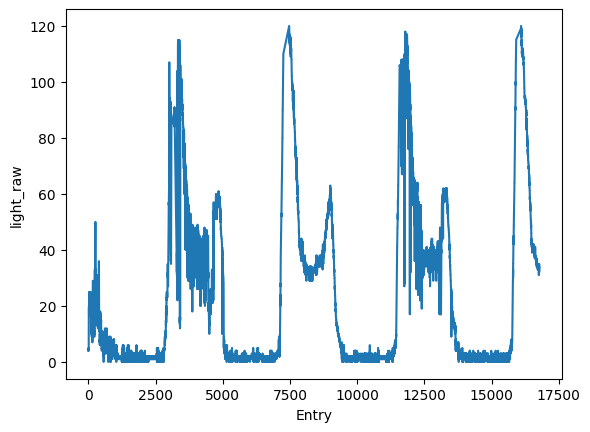

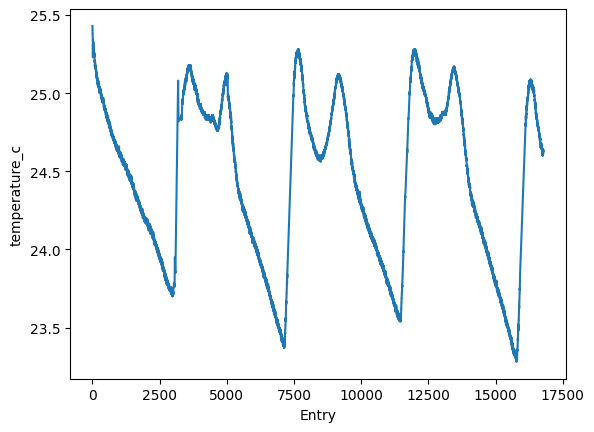

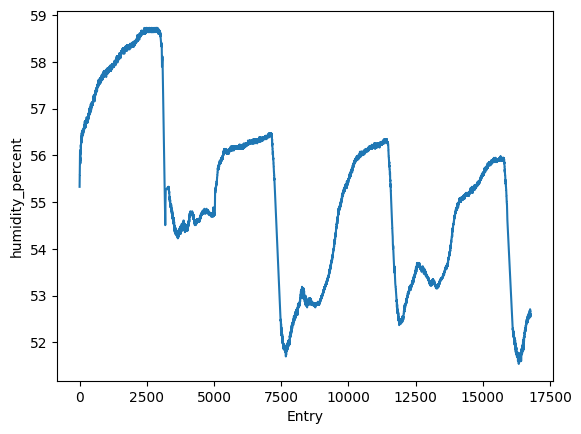

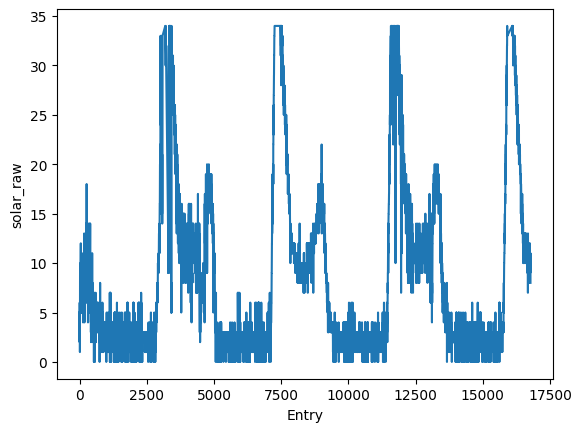

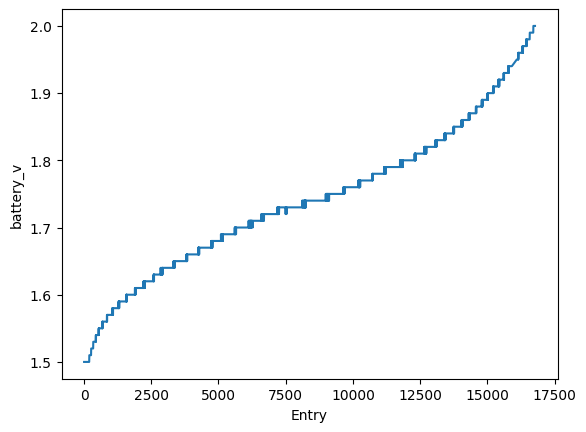

In [14]:
def show_plots(df1):
    print(df1.shape)
    numeric_cols = df1.select_dtypes(include="number").columns

    for col in numeric_cols:

        plt.plot(df1[col])

        plt.xlabel("Entry")
        plt.ylabel(str(col))

        plt.show()
show_plots(df)

##### In a 3 minute window we find the median and swap all values in the window with it. 
##### In timeseries IoT data such as temp, hum, light, minimal chnages happen in 3min. Therefore, to remove local spikes, outliers, false data, and to smoothen out our dataset we avg out values / 3min.

In [15]:
print(len(df.dropna()) - len(df)) #check how many NaN values we have. 

0


### Preprocess done.

## -Feature extraction
##### ---Initial corr. between columns.

In [16]:
corr = df.corr(numeric_only=True).round(4)

print(corr)

                  light_raw  temperature_c  humidity_percent  solar_raw  \
light_raw            1.0000         0.4697           -0.5896     0.9897   
temperature_c        0.4697         1.0000           -0.5930     0.4440   
humidity_percent    -0.5896        -0.5930            1.0000    -0.5384   
solar_raw            0.9897         0.4440           -0.5384     1.0000   
battery_v            0.1793        -0.1641           -0.5700     0.1480   

                  battery_v  
light_raw            0.1793  
temperature_c       -0.1641  
humidity_percent    -0.5700  
solar_raw            0.1480  
battery_v            1.0000  


##### Initial config for our figures and preperation of data

In [17]:
SENSOR_COLS = [
    "temperature_c",
    "humidity_percent",
    "light_raw",
    "solar_raw",
    "battery_v",
]
TIMESTAMP_COL = "timestamp"
PALETTE = "magma"
DARK_BG = "#0f0f14"
ACCENT = "#e8c547"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": "#16161f",
    "axes.edgecolor": "#2a2a3a",
    "axes.labelcolor": "#c8c8d8",
    "xtick.color": "#888899",
    "ytick.color": "#888899",
    "text.color": "#c8c8d8",
    "grid.color": "#1e1e2e",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "monospace",
})


def load_and_prepare(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.set_index(TIMESTAMP_COL)
    df[SENSOR_COLS] = df[SENSOR_COLS].apply(pd.to_numeric, errors="coerce")
    print(f"[LOAD] {len(df)} valid samples | "
          f"{df.index.min()} → {df.index.max()}")
    return df


##### Feature evaluator:

1. Input: feature dataset, target value, how many top X corr. we want to print
2. Used _StandardScaler_ to scale the data down.
3. Calculate F-Score ($\frac{r^2}{1-r^2}(n-2), r = pearson, n = samples$) & p-values
4. Get pearson & spearman scores over all columns
5. Return all metrics
6. Return, per target, the average value of the best scores.

In [18]:

def evaluate_features(feat_df: pd.DataFrame, target: str, top_n=20):

    data = feat_df.select_dtypes(include="number").dropna()

    X = data.drop(columns=[target])
    y = data[target]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    f_scores, p_values = f_regression(X_scaled, y)

    mi_scores = mutual_info_regression(
        X_scaled,
        y,
        random_state=42
    )


    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X, y)

    pearson_scores = X.corrwith(y, method="pearson").abs()
    spearman_scores = X.corrwith(y, method="spearman").abs()

    results = pd.DataFrame({
        "feature": X.columns,
        "pearson": pearson_scores.values,
        "spearman": spearman_scores.values,
        "anova_f": f_scores,
        "anova_p": p_values,
        "mutual_info": mi_scores,
        "random_forest": rf.feature_importances_
    })

    results["pearson_rank"] = results["pearson"].rank(
        ascending=False
    )

    results["spearman_rank"] = results["spearman"].rank(
        ascending=False
    )

    results["anova_rank"] = results["anova_f"].rank(
        ascending=False
    )

    results["mi_rank"] = results["mutual_info"].rank(
        ascending=False
    )

    results["rf_rank"] = results["random_forest"].rank(
        ascending=False
    )

    results["mean_rank"] = (
        results["pearson_rank"] +
        results["spearman_rank"] +
        results["anova_rank"] +
        results["mi_rank"] +
        results["rf_rank"]
    ) / 5

    results = results.sort_values(
        by="mean_rank",
        ascending=True
    )

    print("\n" + "=" * 60)
    print(f"geature importance for target: {target}")
    print("=" * 60)

    print(results.head(top_n))

    return results


Print all features with a _corr. > 0.9_.

In [19]:
def print_best_features(feat_df: pd.DataFrame,
                        corr: pd.DataFrame,
                        threshold=0.90,
                        min_variance=1e-6):

    cols = corr.columns.tolist()

    remove = set()

    variances = feat_df.var()

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):

            c1 = cols[i]
            c2 = cols[j]

            value = corr.iloc[i, j]

            if abs(value) >= threshold:

                v1 = variances[c1]
                v2 = variances[c2]

                if v1 >= v2:
                    remove.add(c2)
                    keep = c1
                    dropped = c2
                else:
                    remove.add(c1)
                    keep = c2
                    dropped = c1

                print(
                    f"[REMOVE] {dropped:<40} "
                    f"| keep={keep:<40} "
                    f"| corr={value:.3f}"
                )

    best_features = [
        c for c in cols
        if c not in remove and variances[c] > min_variance
    ]

    print("\n" + "=" * 60)
    print("BEST FEATURES")
    print("=" * 60)

    for f in best_features:
        print(f)

    print(f"\n[FINAL] {len(best_features)} features kept")

    return best_features


Creates rolling features for all numerics columns with windows of 15, 60, 360 steps (5, 20, 120 mins)

In [20]:

def rolling_features(df: pd.DataFrame, windows_min=[15, 60, 360]) -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        s = df[col]
        for w in windows_min:
            r = s.rolling(f"{w}min", min_periods=2)
            feats[f"{col}__roll_mean_{w}"]  = r.mean()
            feats[f"{col}__roll_std_{w}"]   = r.std()
            feats[f"{col}__roll_range_{w}"] = r.max() - r.min()
    return pd.DataFrame(feats, index=df.index)


Create lag features(prev. measurements.) of 1, 5, 15 steps.

In [21]:


def lag_features(df: pd.DataFrame, lags=[1, 5, 15]) -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        for lag in lags:
            feats[f"{col}__lag_{lag}"] = df[col].shift(lag)
    return pd.DataFrame(feats, index=df.index)


- Defines feature engineering functions:
  - `iqr_features`, `delta_features`, `diurnal_features`, `statistical_features`, `cross_sensor_features`
- Assembles the full feature matrix with `assemble_feature_matrix`
- Computes correlation matrices and p-value matrix
- Adds plotting helpers for raw series, correlation heatmaps, sensor heatmap, rolling correlation, variance, diurnal patterns, and cluster map
- Defines `run_pipeline()` to load data, extract features, evaluate correlations, and save all plots

In [22]:


def iqr_features(df: pd.DataFrame, iqrs=[30, 60, 90, 120, 180, 240]) -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        for iqr in iqrs:
            feats[f"{col}_iqr_{iqr}"] = (
            df[col]
            .rolling(iqr)
            .quantile(0.75)
            -
            df[col]
            .rolling(iqr)
            .quantile(0.25)
        )
    return pd.DataFrame(feats, index=df.index)

def delta_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        feats[f"{col}__delta1"] = df[col].diff(1)
        feats[f"{col}__delta2"] = df[col].diff(1).diff(1)
    return pd.DataFrame(feats, index=df.index)


def diurnal_features(df: pd.DataFrame) -> pd.DataFrame:
    idx = df.index
    hour = idx.hour + idx.minute / 60.0
    feats = {
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "day_of_week": idx.dayofweek.astype(float),
        "is_daytime": ((hour >= 6) & (hour <= 20)).astype(float),
        "hour_bin": pd.cut(hour, bins=[0, 6, 12, 18, 24],
                           labels=[0, 1, 2, 3], right=False).astype(float),
    }
    return pd.DataFrame(feats, index=df.index)


def statistical_features(df: pd.DataFrame, window="1H") -> pd.DataFrame:
    feats = {}
    for col in SENSOR_COLS:
        s = df[col]
        r = s.rolling(window, min_periods=4)
        feats[f"{col}__skew_1h"]  = r.skew()
        feats[f"{col}__kurt_1h"]  = r.kurt()
        mean = r.mean()
        std  = r.std()
        feats[f"{col}__cv_1h"] = (std / mean.replace(0, np.nan)).abs()
    return pd.DataFrame(feats, index=df.index)


def cross_sensor_features(df: pd.DataFrame) -> pd.DataFrame:
    feats = {}
    T = df["temperature_c"]
    H = df["humidity_percent"]
    feats["heat_index_proxy"] = T + 0.33 * (H / 100 * 6.105 *
        np.exp(17.27 * T / (237.7 + T))) - 4.0

    light = df["light_raw"].replace(0, np.nan)
    feats["solar_efficiency"] = df["solar_raw"] / light

    dt_h = df.index.to_series().diff().dt.total_seconds().fillna(0) / 3600
    feats["battery_drain_rate"] = -df["battery_v"].diff() / dt_h.replace(0, np.nan)

    return pd.DataFrame(feats, index=df.index)


def assemble_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    parts = [
        df[SENSOR_COLS],
        rolling_features(df),
        lag_features(df),
        delta_features(df),
        diurnal_features(df),
        statistical_features(df),
        cross_sensor_features(df),
        iqr_features(df)
    ]
    out = pd.concat(parts, axis=1)
    out = out.dropna()
    print(f"matrix shape: {out.shape[0]} rows × {out.shape[1]} columns")
    return out


def compute_correlation_matrices(df: pd.DataFrame):
    pearson  = df.corr(method="pearson")
    spearman = df.corr(method="spearman")
    kendall  = df.corr(method="kendall")
    return pearson, spearman, kendall


def compute_pvalue_matrix(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.columns
    n = len(cols)
    pvals = np.ones((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            s1 = df.iloc[:, i].dropna()
            s2 = df.iloc[:, j].dropna()
            common = s1.index.intersection(s2.index)
            if len(common) > 2:
                _, p = stats.pearsonr(s1[common], s2[common])
                pvals[i, j] = pvals[j, i] = p
    return pd.DataFrame(pvals, index=cols, columns=cols)

def plot_raw_timeseries(df: pd.DataFrame):
    fig, axes = plt.subplots(len(SENSOR_COLS), 1,
                              figsize=(16, 3 * len(SENSOR_COLS)),
                              sharex=True)
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(SENSOR_COLS)))
    for ax, col, c in zip(axes, SENSOR_COLS, colors):
        ax.plot(df.index, df[col], color=c, linewidth=0.8, alpha=0.9)
        ax.fill_between(df.index, df[col], alpha=0.12, color=c)
        ax.set_ylabel(col.replace("_", " "), fontsize=9)
        ax.grid(True)
    axes[-1].set_xlabel("Timestamp")
    fig.suptitle("Raw Data",
                 fontsize=13, fontweight="bold", color=ACCENT, y=1.01)
    fig.tight_layout()
    plt.savefig("01_raw_timeseries.png", dpi=300, bbox_inches="tight",
                facecolor=DARK_BG)
    print("01_raw_timeseries.png")


def plot_correlation_heatmap(corr: pd.DataFrame, pval: pd.DataFrame,
                              method: str, sig_level=0.05):
    sig_mask = pval > sig_level
    tri_mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(14, 12))

    sns.heatmap(
        corr, mask=tri_mask, ax=ax,
        cmap=PALETTE, center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.4, linecolor="#0f0f14",
        annot=False, fmt=".2f", annot_kws={"size": 7, "color": "white"},
        cbar_kws={"shrink": 0.75, "label": f"{method} r"},
    )

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            if not tri_mask[i, j] and sig_mask.iloc[i, j]:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=True, color="#0f0f14", alpha=0.55,
                    hatch="///", linewidth=0
                ))

    ax.set_title(
        f"{method.upper()} Correletion Matrix\n"
        f"(hatched = p > {sig_level}, n={corr.shape[0]} features)",
        fontsize=12, fontweight="bold", color=ACCENT, pad=14
    )
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
    fig.tight_layout()
    fname = f"02_corr_heatmap_{method.lower()}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight", facecolor=DARK_BG)
    print(f"[PLOT] {fname}")

def plot_sensor_only_heatmap(df_raw: pd.DataFrame):
    corr = df_raw[SENSOR_COLS].corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, ax=ax,
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        square=True, annot=True, fmt=".3f",
        linewidths=1, linecolor=DARK_BG,
        annot_kws={"size": 11, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title("Matrix of Raw Data (Pearson)",
                 fontsize=11, fontweight="bold", color=ACCENT)
    fig.tight_layout()
    plt.savefig("03_sensor_corr_heatmap.png", dpi=300,
                bbox_inches="tight", facecolor=DARK_BG)
    print("03_sensor_corr_heatmap.png")


def plot_diurnal_patterns(df: pd.DataFrame):
    df_h = df[SENSOR_COLS].copy()
    df_h["hour"] = df.index.hour

    fig, axes = plt.subplots(1, len(SENSOR_COLS), figsize=(20, 5))
    colors = plt.cm.magma(np.linspace(0.25, 0.85, len(SENSOR_COLS)))
    for ax, col, c in zip(axes, SENSOR_COLS, colors):
        groups = [df_h[df_h["hour"] == h][col].dropna().values
                  for h in range(24)]
        bp = ax.boxplot(groups, positions=range(24), widths=0.6,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color=ACCENT, linewidth=1.5))
        for patch in bp["boxes"]:
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_title(col.replace("_", " "), fontsize=8, color=ACCENT)
        ax.set_xlabel("Hour of Day", fontsize=7)
        ax.set_xticks(range(0, 24, 1))
        ax.set_xticklabels([str(h) for h in range(0, 24, 1)], fontsize=7)
        ax.grid(True)
    fig.suptitle("Hourly Distrbutions",
                 fontsize=12, fontweight="bold", color=ACCENT)
    fig.tight_layout()
    plt.savefig("05_diurnal_boxplots.png", dpi=300,
                bbox_inches="tight", facecolor=DARK_BG)
    print("05_diurnal_boxplots.png")

def run_pipeline(df_raw: pd.DataFrame):
    df = load_and_prepare(df_raw)
    feat_df = assemble_feature_matrix(df)
    pearson, spearman, _ = compute_correlation_matrices(feat_df)
    best_features = print_best_features(feat_df, pearson)
    pval = compute_pvalue_matrix(feat_df)
    feature_scores_temp = evaluate_features(
        feat_df,
        target="temperature_c",
        top_n=30
    )

    feature_scores_humidity = evaluate_features(
        feat_df,
        target="humidity_percent",
        top_n=30
    )

    feature_scores_light = evaluate_features(
        feat_df,
        target="light_raw",
        top_n=30
    )

    plot_raw_timeseries(df)
    plot_correlation_heatmap(pearson,  pval, method="Pearson")
    plot_correlation_heatmap(spearman, pval, method="Spearman")
    plot_sensor_only_heatmap(df)
    plot_diurnal_patterns(df)

    print("\n[DONE] All 7 plots saved.")
    return feat_df, pearson, spearman, feature_scores_temp, feature_scores_humidity, feature_scores_light


[LOAD] 16775 valid samples | 2026-05-16 12:38:16.398000+00:00 → 2026-05-20 09:49:31.666000+00:00
matrix shape: 16096 rows × 128 columns
[REMOVE] temperature_c                            | keep=temperature_c__roll_mean_15              | corr=0.997
[REMOVE] temperature_c__roll_mean_60              | keep=temperature_c                            | corr=0.967
[REMOVE] temperature_c                            | keep=temperature_c__lag_1                     | corr=1.000
[REMOVE] temperature_c                            | keep=temperature_c__lag_5                     | corr=1.000
[REMOVE] temperature_c                            | keep=temperature_c__lag_15                    | corr=0.998
[REMOVE] temperature_c                            | keep=heat_index_proxy                         | corr=0.969
[REMOVE] humidity_percent__roll_mean_15           | keep=humidity_percent                         | corr=0.999
[REMOVE] humidity_percent__roll_mean_60           | keep=humidity_percent              

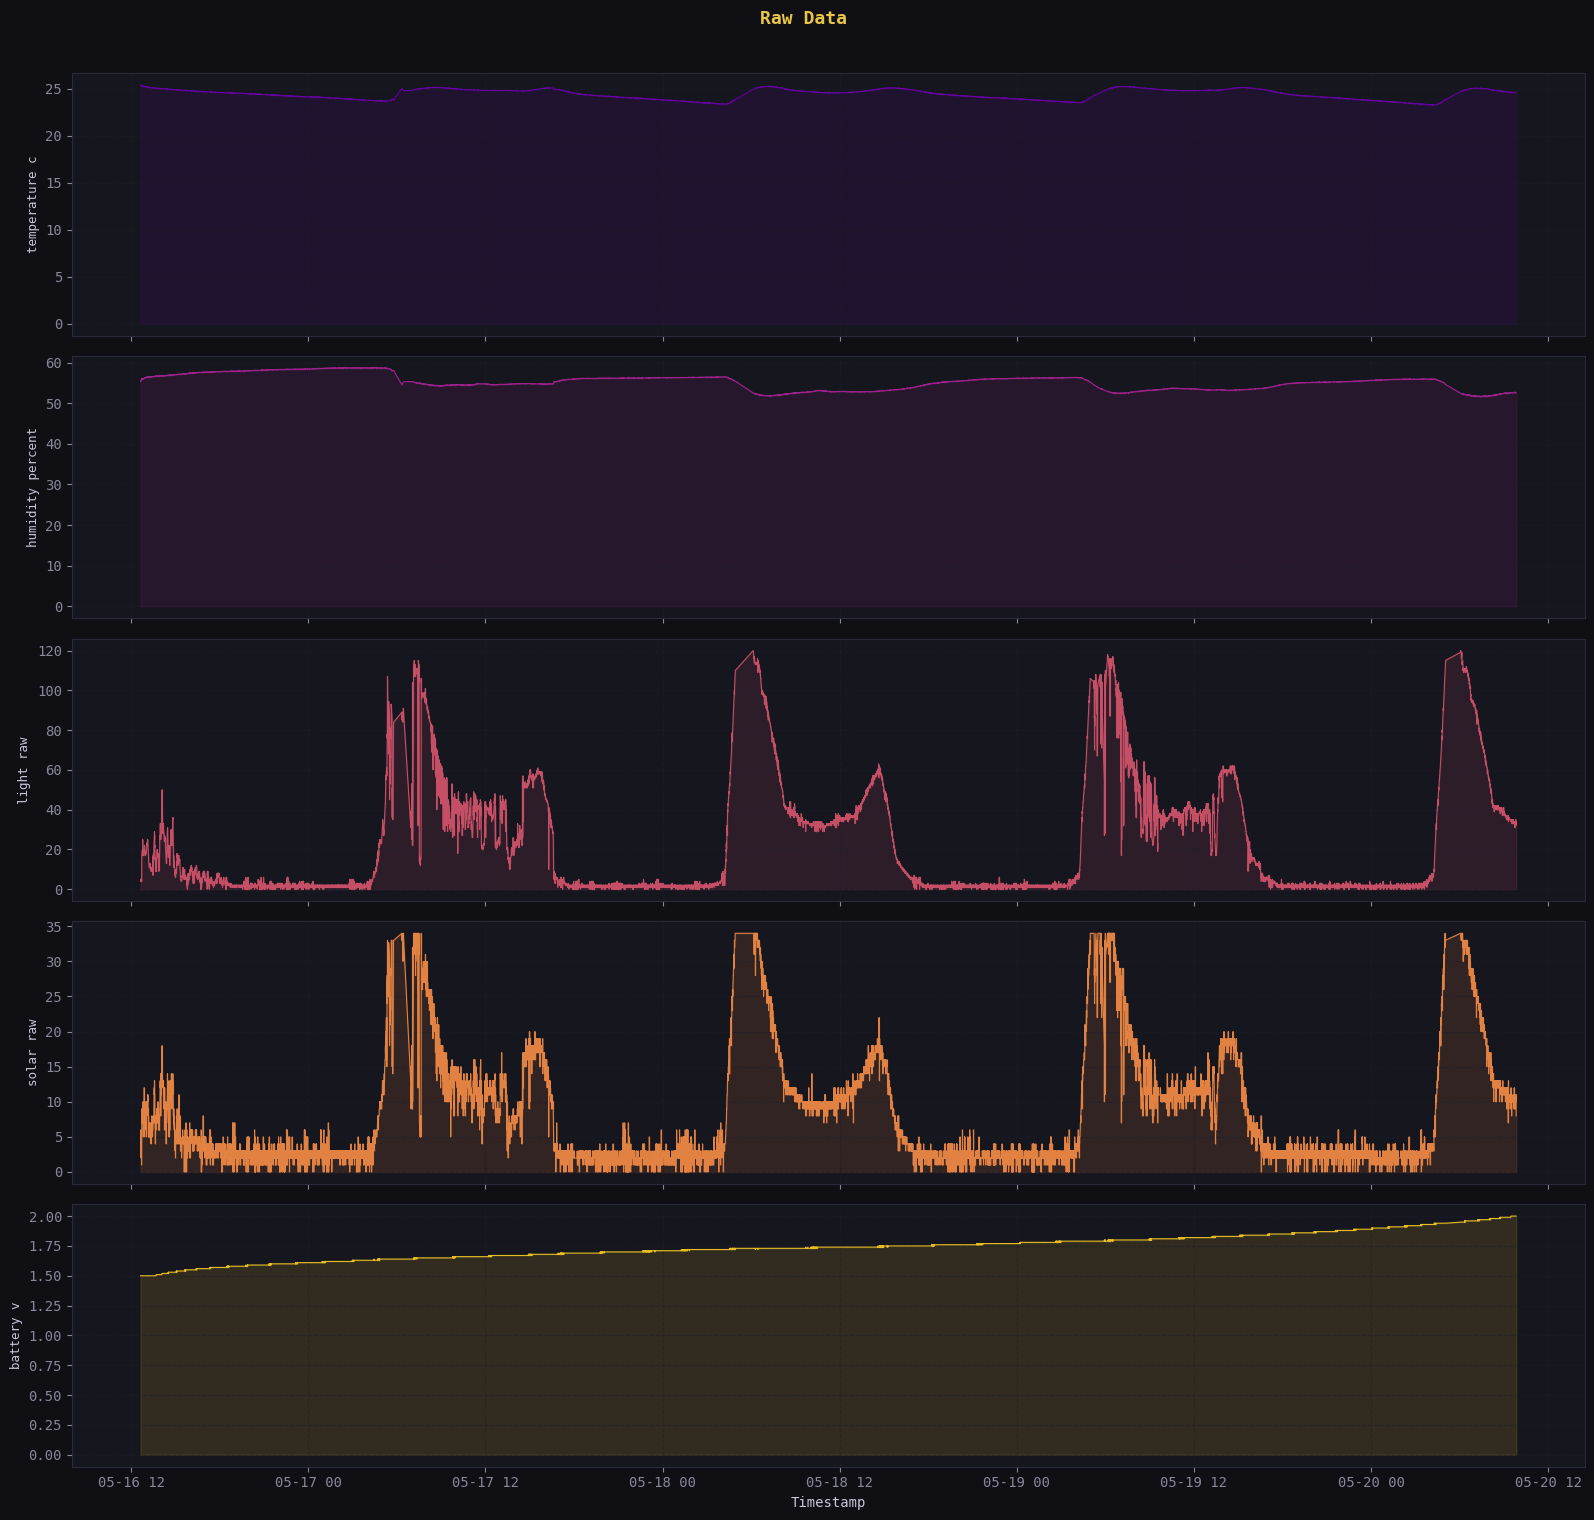

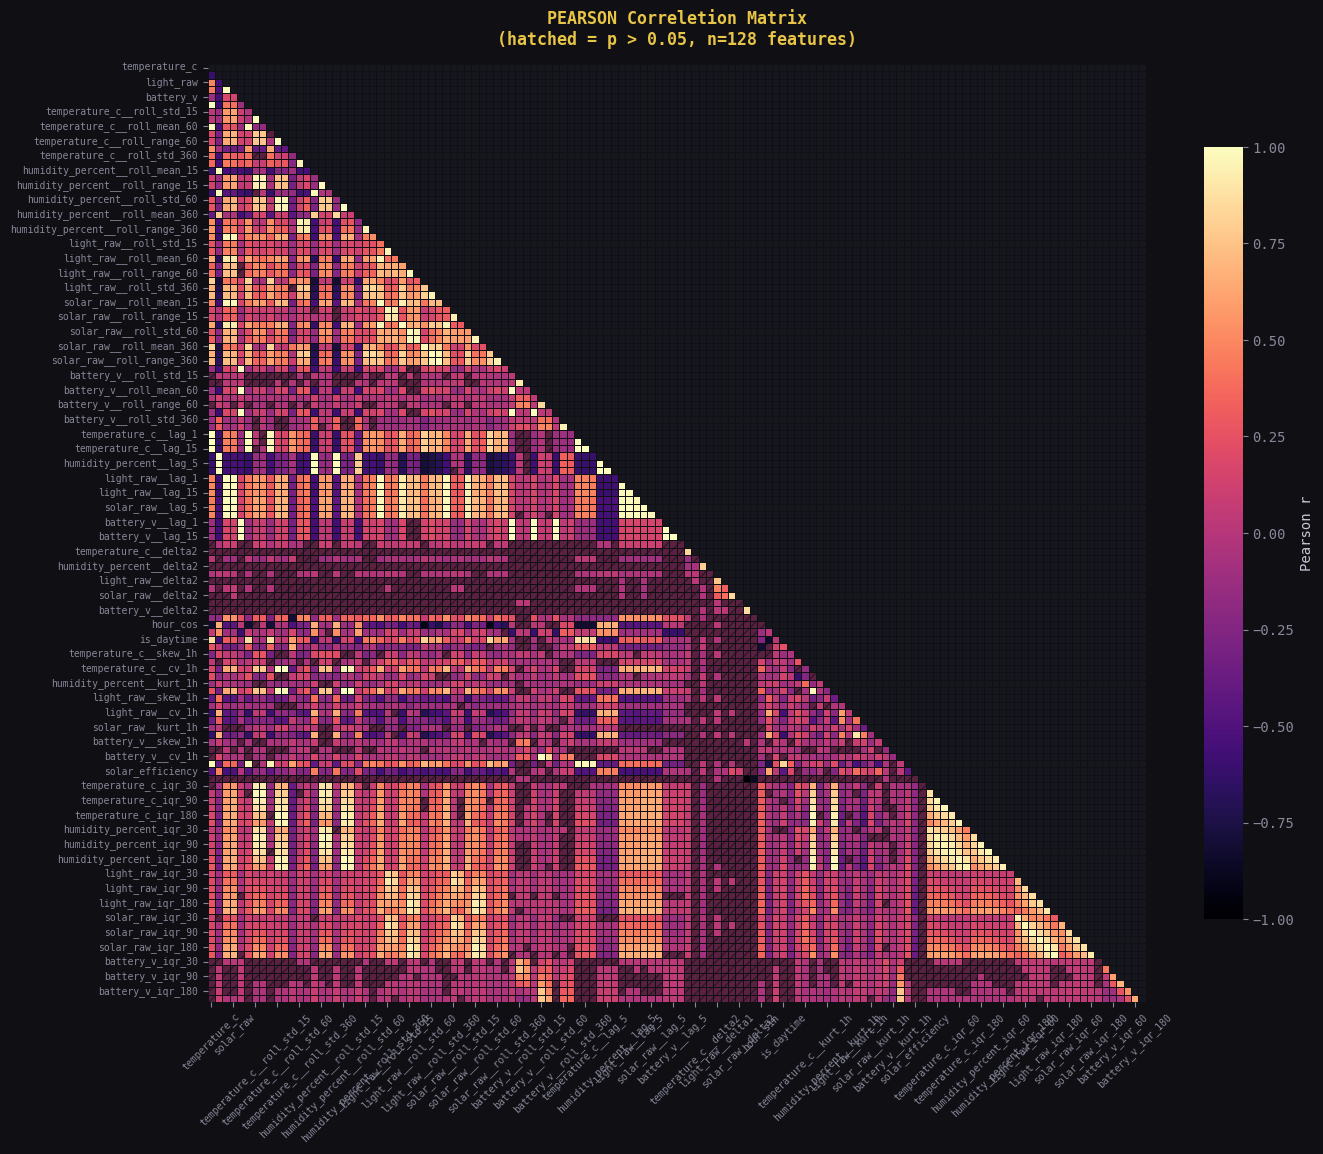

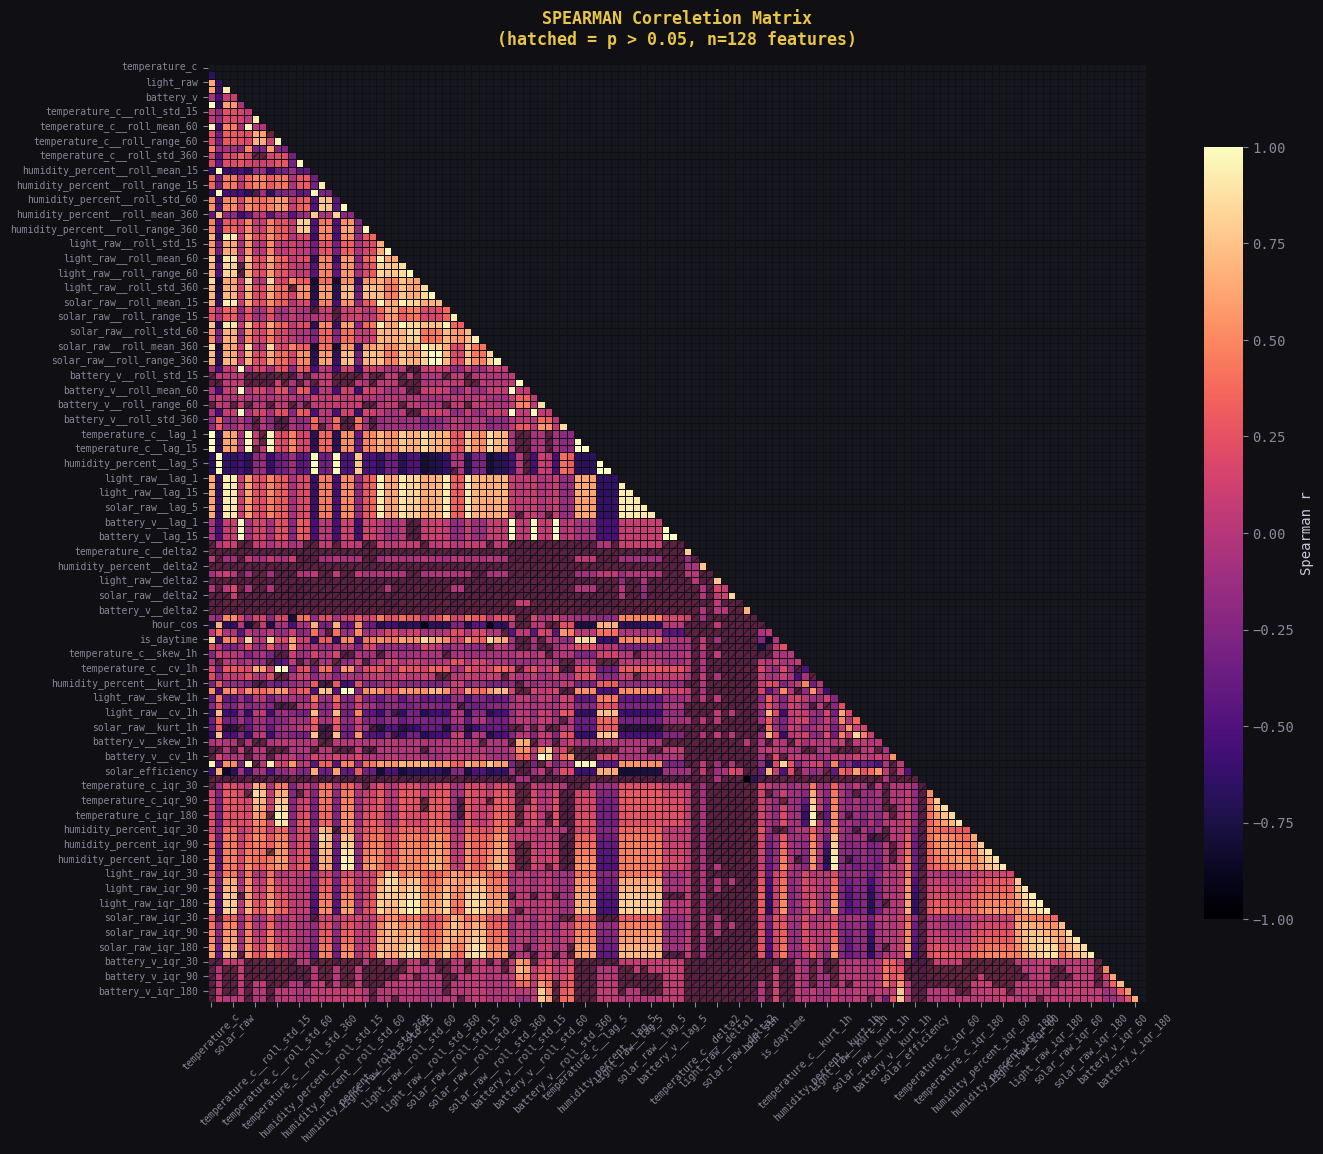

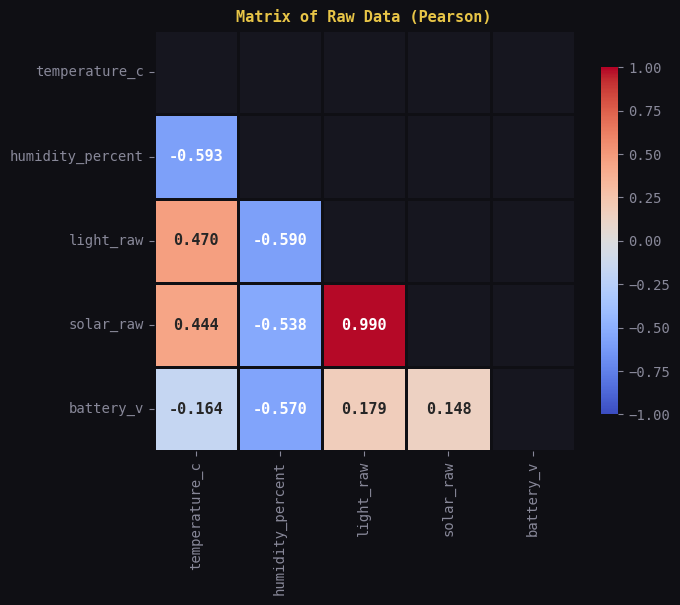

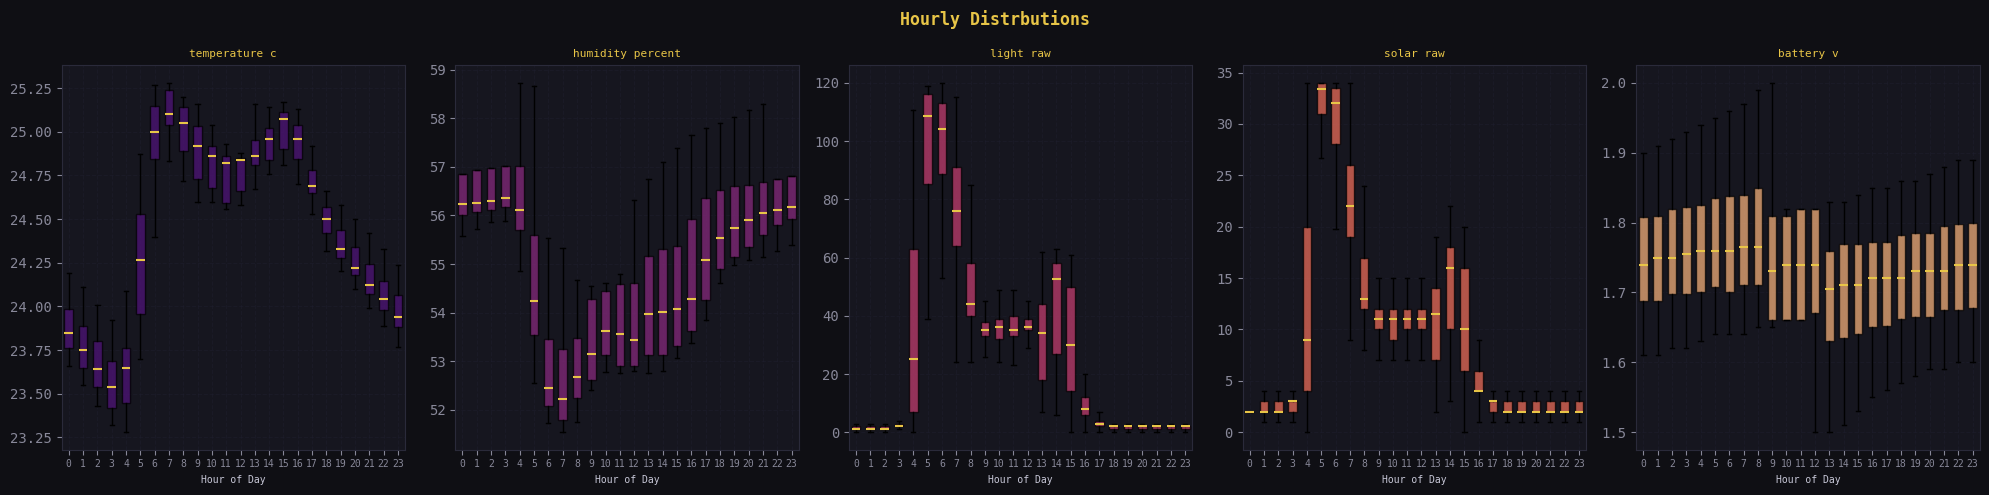

In [23]:
from pathlib import Path

if Path("pipeline_results.pkl").exists():

    data = pd.read_pickle(
        "pipeline_results.pkl"
    )

    feat_df = data["feat_df"]
    pearson = data["pearson"]
    spearman = data["spearman"]

    feature_scores_temp = (
        data["feature_scores_temp"]
    )

    feature_scores_humidity = (
        data["feature_scores_humidity"]
    )

    feature_scores_light = (
        data["feature_scores_light"]
    )

else:

    (
        feat_df,
        pearson,
        spearman,
        feature_scores_temp,
        feature_scores_humidity,
        feature_scores_light
    ) = run_pipeline(df)

    data = {
        "feat_df": feat_df,
        "pearson": pearson,
        "spearman": spearman,
        "feature_scores_temp": (
            feature_scores_temp
        ),
        "feature_scores_humidity": (
            feature_scores_humidity
        ),
        "feature_scores_light": (
            feature_scores_light
        )
    }

    pd.to_pickle(
        data,
        "pipeline_results.pkl"
    )

print(feature_scores_temp.head(30))
print(feature_scores_humidity.head(30))
print(feature_scores_light.head(30))

We kept top features with high correlation. 

- Creates lag features for `temperature_c`, `humidity_percent`, and `light_raw`
- Computes `minutes` of day and a 15-step centered smoothed temperature
- Derives `temp_gradient` and classifies `day_phase` as `night`, `sunrise`, `sunset`, or `day_peak`
- Adds first-order deltas and cyclical time features:
  - $\sin\!\left(\frac{2\pi t}{86400}\right)$
  - $\cos\!\left(\frac{2\pi t}{86400}\right)$
- Adds a humidity–temperature interaction term
- Computes 60-step rolling IQR for temperature, humidity, and light
- Adds 5-step and 15-step lag features for temperature, humidity, and light
- Drops rows with missing values after feature generation

In [24]:
df["temp_lag_1"] = df["temperature_c"].shift(1)

df["humidity_lag_1"] = (
    df["humidity_percent"].shift(1)
)

df["light_lag_1"] = (
    df["light_raw"].shift(1)
)

df["minutes"] = (
    df["timestamp"].dt.hour * 60 +
    df["timestamp"].dt.minute
)

df["temp_smooth"] = (
    df["temperature_c"]
    .rolling(15, center=True)
    .mean()
)

df["temp_gradient"] = (
    df["temp_smooth"]
    .diff()
)

def get_phase(row):
    temp_grad = row["temp_gradient"]
    light = row["light_raw"]
    temp = row["temp_smooth"]

    if light < 10:
        return "night"

    elif temp_grad > 0.01:
        return "sunrise"

    elif temp_grad < -0.01:
        return "sunset"

    else:
        return "day_peak"
    

df = df.dropna()

df["day_phase"] = df.apply(
    get_phase,
    axis=1
)

df["temp_delta_1"] = (
    df["temperature_c"].diff(1)
)

df["humidity_delta_1"] = (
    df["humidity_percent"].diff(1)
)

df["light_delta_1"] = (
    df["light_raw"].diff(1)
)

seconds = (
    df["timestamp"].dt.hour * 3600 +
    df["timestamp"].dt.minute * 60 +
    df["timestamp"].dt.second
)

day = 24 * 3600

df["time_sin"] = np.sin(
    2 * np.pi * seconds / day
)

df["time_cos"] = np.cos(
    2 * np.pi * seconds / day
)

df["humidity_temp_interaction"] = (
    df["humidity_percent"] *
    df["temperature_c"]
)

df["temp_iqr_60"] = (
    df["temperature_c"]
    .rolling(60)
    .quantile(0.75)
    -
    df["temperature_c"]
    .rolling(60)
    .quantile(0.25)
)

df["humidity_iqr_60"] = (
    df["humidity_percent"]
    .rolling(60)
    .quantile(0.75)
    -
    df["humidity_percent"]
    .rolling(60)
    .quantile(0.25)
)

df["light_iqr_60"] = (
    df["light_raw"]
    .rolling(60)
    .quantile(0.75)
    -
    df["light_raw"]
    .rolling(60)
    .quantile(0.25)
)

df["temp_lag_5"] = df["temperature_c"].shift(5)
df["temp_lag_15"] = df["temperature_c"].shift(15)

df["humidity_lag_5"] = (
    df["humidity_percent"].shift(5)
)

df["light_lag_5"] = (
    df["light_raw"].shift(5)
)

df = df.dropna()

In [25]:
print(df.columns)

Index(['timestamp', 'light_raw', 'temperature_c', 'humidity_percent',
       'solar_raw', 'battery_v', 'temp_lag_1', 'humidity_lag_1', 'light_lag_1',
       'minutes', 'temp_smooth', 'temp_gradient', 'day_phase', 'temp_delta_1',
       'humidity_delta_1', 'light_delta_1', 'time_sin', 'time_cos',
       'humidity_temp_interaction', 'temp_iqr_60', 'humidity_iqr_60',
       'light_iqr_60', 'temp_lag_5', 'temp_lag_15', 'humidity_lag_5',
       'light_lag_5'],
      dtype='object')


- Selects the target columns: `temperature_c`, `humidity_percent`, `light_raw`
- Drops targets plus `timestamp` and `day_phase` from the feature set
- Builds predictor matrix `X` and target matrix `y`
- Resets both indices so training and testing slices align
- Creates a time-aware split with `TimeSeriesSplit(n_splits=6)`

In [26]:
horizon = 100

df["target_temp"] = df["temperature_c"].shift(-horizon)
df["target_humidity"] = df["humidity_percent"].shift(-horizon)
df["target_light"] = df["light_raw"].shift(-horizon)

df = df.dropna().reset_index(drop=True)

target_cols = [
    "target_temp",
    "target_humidity",
    "target_light"
]

drop_cols = [
    "timestamp",
    "day_phase"
] + target_cols

X = df.drop(columns=drop_cols)
y = df[target_cols]

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

tscv = TimeSeriesSplit(
    n_splits=6)

all_scores = []
all_preds = {col: [] for col in y.columns}
all_real = {col: [] for col in y.columns}


DARK_BG = "white"

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    print("Fold:", fold + 1, "done")


    for i, col in enumerate(y.columns):

        all_preds[col].extend(y_pred[:, i])

        all_real[col].extend(
        y_test[col].values
    )

        plt.figure(figsize=(15, 5))

        plt.plot(
            y_test[col].values,
            label="Real",
            linewidth=2,
            alpha=0.8
        )

        plt.plot(
            y_pred[:, i],
            label="Predicted",
            linestyle="--",
            alpha=0.8,
            linewidth=2
        )

        plt.title(f"Target: {col} | Fold {fold + 1}")
        plt.ylabel(col)
        plt.xlabel("Entry")
        plt.grid(alpha=0.3)
        plt.legend()

        fname = f"{col.lower()}_fold_{fold + 1}_pred.png"

        plt.savefig(
            fname,
            dpi=600,
            bbox_inches="tight",
            facecolor=DARK_BG
        )

        plt.close()

    for i, col in enumerate(y.columns):

        real = y_test[col]
        pred = y_pred[:, i]

        mae = mean_absolute_error(real, pred)
        mse = mean_squared_error(real, pred)
        rmse = np.sqrt(mse)

        train_r2 = r2_score(
            y_train[col],
            train_pred[:, i]
        )

        test_r2 = r2_score(
            y_test[col],
            y_pred[:, i]
        )

        overfitting_gap = train_r2 - test_r2

        median_ae = median_absolute_error(real, pred)
        explained_var = explained_variance_score(real, pred)
        max_err = max_error(real, pred)
        residual_mean = np.mean(real - pred)

        all_scores.append({
            "fold": fold + 1,
            "target": col,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "Train R2": train_r2,
            "Test R2": test_r2,
            "Median Absolute Error": median_ae,
            "Explained Variance": explained_var,
            "Max Error": max_err,
            "Residual Mean": residual_mean,
            "overfitting_gap_r2": overfitting_gap
        })

scores_df = pd.DataFrame(all_scores)

summary = (
    scores_df
    .drop(columns="fold")
    .groupby("target")
    .mean(numeric_only=True)
)

progress_df = scores_df.sort_values(
    by=["target", "fold"]
)

progress_df = progress_df.set_index(
    ["target", "fold"]
)

print(progress_df)

excel_filename = "time_series_metrics.xlsx"

with pd.ExcelWriter(
    excel_filename,
    engine="openpyxl",
    mode="w"
) as writer:

    summary.to_excel(
        writer,
        sheet_name="Overall Summary"
    )

    progress_df.to_excel(
        writer,
        sheet_name="Fold Progress"
    )

    print(f"\nSuccessfully appended blocks to '{excel_filename}'")

Fold: 1 done
Fold: 2 done
Fold: 3 done
Fold: 4 done
Fold: 5 done
Fold: 6 done
                            MAE          MSE       RMSE  Train R2   Test R2  \
target          fold                                                          
target_humidity 1      1.006951     1.464891   1.210327  0.995901  0.479717   
                2      0.188014     0.060721   0.246417  0.980751  0.634406   
                3      0.425359     0.284613   0.533491  0.978373  0.454954   
                4      0.148376     0.030752   0.175361  0.988828  0.977695   
                5      0.098061     0.015778   0.125609  0.988618  0.968688   
                6      0.183639     0.045722   0.213826  0.989760  0.982614   
target_light    1     36.040655  2197.125329  46.873503  0.783405 -1.756336   
                2     26.053953   926.506860  30.438575  0.799941 -1.285172   
                3     17.031023   503.946148  22.448745  0.775374  0.534655   
                4      8.894902   203.137223  14.2526

In [27]:
target_columns_to_plot = [
    "target_temp",
    "target_humidity",
    "target_light"
]

for col in target_columns_to_plot:

    plt.figure(figsize=(18, 5))

    plt.plot(
        all_real[col],
        label="Real",
        linewidth=2.5,
        alpha=0.7,
        color="royalblue"
    )

    plt.plot(
        all_preds[col],
        label="Predicted",
        linestyle="--",
        linewidth=1.5,
        color="darkorange"
    )

    plt.title("Summary of train-test")
    plt.xlabel("Entry")
    plt.ylabel(col)

    plt.legend(loc="upper left")

    plt.grid(True, alpha=0.15)

    fname = f"{col}_predicted_summary.png"

    plt.savefig(
        fname,
        dpi=600,
        bbox_inches="tight",
        facecolor=DARK_BG
    )

    plt.close()

In [28]:
print(df.shape)

(16601, 29)


In [29]:
print(df.columns)

Index(['timestamp', 'light_raw', 'temperature_c', 'humidity_percent',
       'solar_raw', 'battery_v', 'temp_lag_1', 'humidity_lag_1', 'light_lag_1',
       'minutes', 'temp_smooth', 'temp_gradient', 'day_phase', 'temp_delta_1',
       'humidity_delta_1', 'light_delta_1', 'time_sin', 'time_cos',
       'humidity_temp_interaction', 'temp_iqr_60', 'humidity_iqr_60',
       'light_iqr_60', 'temp_lag_5', 'temp_lag_15', 'humidity_lag_5',
       'light_lag_5', 'target_temp', 'target_humidity', 'target_light'],
      dtype='object')


### ARIMAX Forecasting and Time-Series Evaluation

Processes and prepares the environmental sensor data for ARIMAX forecasting by converting timestamps, sorting entries chronologically, and selecting the target and feature variables used during training. A SARIMAX model with exogenous variables is then applied using time-series cross-validation to predict temperature, humidity, and light measurements. For every fold, prediction performance is evaluated using MAE, MSE, RMSE, and \(R^2\), while both predictions and evaluation results are stored for further analysis and comparison.

In [30]:

df_arimax = df.copy()

df_arimax["timestamp"] = pd.to_datetime(
    df_arimax["timestamp"],
    format="mixed",
    utc=True
)

df_arimax = (
    df_arimax
    .sort_values("timestamp")
    .reset_index(drop=True)
)

targets = [
    "temperature_c",
    "humidity_percent",
    "light_raw"
]

feature_cols = [
    "solar_raw",
    "battery_v",
    "time_sin",
    "time_cos",
    "temp_lag_1",
    "humidity_lag_1",
    "light_lag_1"
]

for col in targets + feature_cols:

    df_arimax[col] = pd.to_numeric(
        df_arimax[col],
        errors="coerce"
    )

df_arimax = df_arimax.dropna().reset_index(drop=True)

tscv = TimeSeriesSplit(
    n_splits=6)

all_scores = []
all_predictions = []

for target in targets:

    print()
    print("TARGET:", target)

    y = df_arimax[target]

    X = df_arimax[feature_cols]

    for fold, (train_idx, test_idx) in enumerate(tscv.split(y)):

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        model = SARIMAX(
            y_train,
            exog=X_train,
            order=(2, 0, 1),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model.fit(
            disp=False
        )

        pred = model_fit.forecast(
            steps=len(y_test),
            exog=X_test
        )

        mae = mean_absolute_error(
            y_test,
            pred
        )

        mse = mean_squared_error(
            y_test,
            pred
        )

        rmse = np.sqrt(mse)

        r2 = r2_score(
            y_test,
            pred
        )

        all_scores.append({
            "target": target,
            "fold": fold + 1,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        })

        fold_predictions = pd.DataFrame({
            "target": target,
            "fold": fold + 1,
            "timestamp": df_arimax["timestamp"].iloc[test_idx].values,
            "actual": y_test.values,
            "predicted": pred.values
        })

        all_predictions.append(
            fold_predictions
        )

        print("Fold:", fold + 1)
        print("MAE:", mae)
        print("MSE:", mse)
        print("RMSE:", rmse)
        print("R2:", r2)

scores_df = pd.DataFrame(
    all_scores
)

predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

scores_excel = scores_df.pivot(
    index="fold",
    columns="target",
    values=["MAE", "MSE", "RMSE", "R2"]
)

scores_excel = scores_excel.swaplevel(
    0,
    1,
    axis=1
)

scores_excel = scores_excel.sort_index(
    axis=1,
    level=0
)

scores_excel.to_excel(
    "sarimax.xlsx",
    sheet_name="scores"
)


TARGET: temperature_c
Fold: 1
MAE: 0.06741202569918985
MSE: 0.005981484698595373
RMSE: 0.07734005882203202
R2: 0.9764856357192738


c:\Users\tasis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fold: 2
MAE: 0.008238663562528071
MSE: 0.00012530835879596188
RMSE: 0.011194121617883284
R2: 0.9994965502618


c:\Users\tasis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fold: 3
MAE: 0.00696664768163833
MSE: 9.04659894816659e-05
RMSE: 0.009511361074087446
R2: 0.999119291044619


...

Fold: 4
MAE: 2.1241038943959403
MSE: 9.294086893730078
RMSE: 3.0486204902759018
R2: 0.9932321462072108


c:\Users\tasis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fold: 5
MAE: 2.3536398336003543
MSE: 11.277138401579723
RMSE: 3.358145083461958
R2: 0.9790966517689661


c:\Users\tasis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fold: 6
MAE: 2.5424876931670157
MSE: 11.698469121164804
RMSE: 3.420302489717072
R2: 0.9933989558418193
